# SVM (RBF) Drowsy Detection

This notebook trains and evaluates an SVM model with RBF kernel.

**Why training feels stuck:** There is usually **no bug**. `sklearn.svm.SVC` with `kernel="rbf"` has **super-linear** runtime and memory needs (often impractical beyond tens of thousands of samples). Your train split has **~186k rows**, so `fit` can take **hours or worse**. Below we **stratified-subsample only the training portion** used for `fit`; the **test split stays full** for metrics.

It includes:
- Data loading and preprocessing
- Train/test evaluation
- Full metrics (Accuracy, Precision, Recall, F1, ROC-AUC)
- Confusion matrix and classification report
- 5-fold stratified cross-validation stability check
- Saving model and reports

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    StratifiedShuffleSplit,
)
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

sns.set(style="whitegrid")
np.random.seed(42)

print("Imports loaded.")

Imports loaded.


In [2]:
# Setup paths
window_features_path = "window_features.csv"
output_dir = "svm-outputs"
os.makedirs(output_dir, exist_ok=True)

print("window_features.csv exists:", os.path.exists(window_features_path))
if not os.path.exists(window_features_path):
    raise FileNotFoundError("window_features.csv not found. Generate it first.")

print("Output directory:", output_dir)

window_features.csv exists: True
Output directory: svm-outputs


In [3]:
# Load and prepare data
df = pd.read_csv(window_features_path)
display(df.head())

required_cols = {"label", "subject", "video_path"}
missing_required = required_cols - set(df.columns)
if missing_required:
    raise ValueError(f"Missing required columns: {sorted(missing_required)}")

le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])

drop_cols = [c for c in ["label", "y", "subject", "video_path"] if c in df.columns]
X = df.drop(columns=drop_cols).fillna(0)
y = df["y"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", list(le.classes_))
print("Class distribution:")
print(y.value_counts().sort_index())

,subject,video_path,label,EAR_mean,EAR_std,EAR_min,MAR_mean,MAR_max,pitch_mean,yaw_mean,EAR_dev_mean,MAR_dev_mean
0,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.237036,0.037249,0.137103,0.036132,0.199047,370.103525,635.342636,-0.016333,0.026740
1,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.247254,0.045480,0.137103,0.035163,0.199047,332.952045,581.059837,-0.006115,0.025772
2,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.252945,0.050826,0.137103,0.029647,0.199047,327.099773,572.753631,-0.000425,0.020256
3,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.257431,0.055144,0.137103,0.030483,0.199047,314.021163,556.392134,0.004062,0.021092
4,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.256823,0.055100,0.137103,0.018152,0.042090,303.104617,530.404469,0.003454,0.008761


X shape: (233591, 9)
y shape: (233591,)
Classes: ['Alert', 'Drowsy', 'Low Vigilance']
Class distribution:
y
0    78094
1    78465
2    77032
Name: count, dtype: int64


In [4]:
# Train/test split + scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", len(y_train))
print("Test size:", len(y_test))

Train size: 186872
Test size: 46719


In [5]:
# Train SVM (RBF)
# RBF SVC does not scale to ~186k training rows — stratified subsample for fit only.
# Raise this slowly (e.g. 25k–40k) if you have time; full data needs approximate/kernel methods.
MAX_SVM_TRAIN_SAMPLES = 15_000

svm_config = {
    "kernel": "rbf",
    "C": 10.0,
    "gamma": "scale",
    "probability": True,
    "class_weight": "balanced",
    "random_state": 42,
}

if len(y_train) > MAX_SVM_TRAIN_SAMPLES:
    sss = StratifiedShuffleSplit(
        n_splits=1,
        train_size=MAX_SVM_TRAIN_SAMPLES,
        random_state=42,
    )
    idx_fit, _ = next(sss.split(np.zeros(len(y_train)), y_train))
    X_fit = X_train_scaled[idx_fit]
    y_fit = np.asarray(y_train.iloc[idx_fit])
    print(
        f"SVC fit uses stratified train subset: {len(y_fit):,} / {len(y_train):,} rows"
    )
else:
    X_fit = X_train_scaled
    y_fit = np.asarray(y_train)
    print(f"SVC fit uses full train split: {len(y_fit):,} rows")

svm_model = SVC(**svm_config)
svm_model.fit(X_fit, y_fit)

print("SVM model trained.")
print("Config:", svm_config)

SVC fit uses stratified train subset: 15,000 / 186,872 rows
SVM model trained.
Config: {'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale', 'probability': True, 'class_weight': 'balanced', 'random_state': 42}


In [6]:
# Test set evaluation
y_pred = svm_model.predict(X_test_scaled)
y_proba = svm_model.predict_proba(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec_w = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec_w = recall_score(y_test, y_pred, average="weighted")
f1_w = f1_score(y_test, y_pred, average="weighted")
f1_m = f1_score(y_test, y_pred, average="macro")
roc_auc_w = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")

print("Test Metrics")
print("=" * 50)
print(f"Accuracy:            {acc:.4f}")
print(f"Precision (weighted): {prec_w:.4f}")
print(f"Recall (weighted):    {rec_w:.4f}")
print(f"F1 (weighted):        {f1_w:.4f}")
print(f"F1 (macro):           {f1_m:.4f}")
print(f"ROC-AUC (weighted):   {roc_auc_w:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Test Metrics
Accuracy:            0.7089
Precision (weighted): 0.7168
Recall (weighted):    0.7089
F1 (weighted):        0.7058
F1 (macro):           0.7056
ROC-AUC (weighted):   0.8796

Classification Report:
               precision    recall  f1-score   support

        Alert       0.68      0.86      0.76     15619
       Drowsy       0.79      0.61      0.69     15693
Low Vigilance       0.67      0.66      0.66     15407

     accuracy                           0.71     46719
    macro avg       0.72      0.71      0.71     46719
 weighted avg       0.72      0.71      0.71     46719



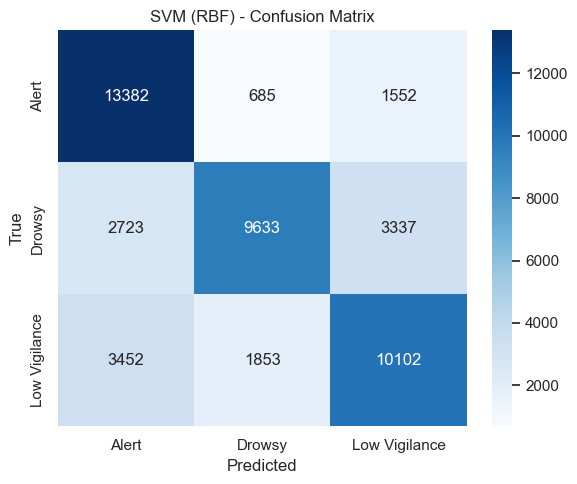

Saved: confusion_matrix.png


In [7]:
# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)
plt.title("SVM (RBF) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")

In [8]:
# 5-fold CV stability check (subset + Pipeline so scaler fits inside each fold only)
CV_MAX_SAMPLES = 20_000
if len(y) > CV_MAX_SAMPLES:
    sss_cv = StratifiedShuffleSplit(
        n_splits=1, train_size=CV_MAX_SAMPLES, random_state=123
    )
    idx_cv, _ = next(sss_cv.split(np.zeros(len(y)), y))
    X_cv = X.iloc[idx_cv]
    y_cv = y.iloc[idx_cv]
    print(f"CV uses stratified subset: {len(y_cv):,} / {len(y):,} rows")
else:
    X_cv = X
    y_cv = y
    print(f"CV uses full data: {len(y_cv):,} rows")

cv_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("svc", SVC(**svm_config)),
    ]
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision_weighted": "precision_weighted",
    "recall_weighted": "recall_weighted",
    "f1_weighted": "f1_weighted",
    "f1_macro": "f1_macro",
    "roc_auc_weighted": "roc_auc_ovr_weighted",
}

cv_results = cross_validate(
    cv_pipe,
    X_cv,
    y_cv,
    cv=skf,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False,
)

cv_df = pd.DataFrame({
    "fold": np.arange(1, 6),
    "accuracy": cv_results["test_accuracy"],
    "precision_weighted": cv_results["test_precision_weighted"],
    "recall_weighted": cv_results["test_recall_weighted"],
    "f1_weighted": cv_results["test_f1_weighted"],
    "f1_macro": cv_results["test_f1_macro"],
    "roc_auc_weighted": cv_results["test_roc_auc_weighted"],
})

display(cv_df)

summary = {}
for col in ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted", "f1_macro", "roc_auc_weighted"]:
    mean_v = cv_df[col].mean()
    std_v = cv_df[col].std()
    cvp = (std_v / mean_v) * 100
    summary[col] = {
        "mean": float(mean_v),
        "std": float(std_v),
        "min": float(cv_df[col].min()),
        "max": float(cv_df[col].max()),
        "cv_percent": float(cvp),
    }

acc_mean = summary["accuracy"]["mean"]
acc_std = summary["accuracy"]["std"]
acc_sem = stats.sem(cv_df["accuracy"]) if len(cv_df) > 1 else 0.0
ci95 = stats.t.interval(0.95, len(cv_df) - 1, loc=acc_mean, scale=acc_sem) if len(cv_df) > 1 else (acc_mean, acc_mean)

print("\nCV Summary")
print("=" * 50)
print(f"Mean Accuracy: {acc_mean:.4f} +/- {acc_std:.4f}")
print(f"95% CI: [{ci95[0]:.4f}, {ci95[1]:.4f}]")
print(f"Accuracy CV%: {summary['accuracy']['cv_percent']:.2f}%")

CV uses stratified subset: 20,000 / 233,591 rows


,fold,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro,roc_auc_weighted
0,1,0.72075,0.730910,0.72075,0.717893,0.717767,0.883495
1,2,0.71350,0.723223,0.71350,0.709843,0.709729,0.881236
2,3,0.71700,0.727697,0.71700,0.714511,0.714272,0.888500
3,4,0.71600,0.723472,0.71600,0.713171,0.713019,0.883431
4,5,0.70750,0.716378,0.70750,0.704211,0.704072,0.881140



CV Summary
Mean Accuracy: 0.7150 +/- 0.0049
95% CI: [0.7088, 0.7211]
Accuracy CV%: 0.69%


In [9]:
# Save artifacts
test_metrics = {
    "accuracy": float(acc),
    "precision_weighted": float(prec_w),
    "recall_weighted": float(rec_w),
    "f1_weighted": float(f1_w),
    "f1_macro": float(f1_m),
    "roc_auc_weighted": float(roc_auc_w),
}

cv_df.to_csv(os.path.join(output_dir, "cv_fold_results.csv"), index=False)
pd.DataFrame([test_metrics]).to_csv(os.path.join(output_dir, "test_metrics.csv"), index=False)

with open(os.path.join(output_dir, "cv_summary.json"), "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4)

report_dict = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
with open(os.path.join(output_dir, "classification_report.json"), "w", encoding="utf-8") as f:
    json.dump(report_dict, f, indent=4)

joblib.dump(svm_model, os.path.join(output_dir, "svm_rbf_model.pkl"))
joblib.dump(scaler, os.path.join(output_dir, "scaler.pkl"))
joblib.dump(le, os.path.join(output_dir, "label_encoder.pkl"))
joblib.dump(list(X.columns), os.path.join(output_dir, "feature_columns.pkl"))

print("Saved files:")
print("- cv_fold_results.csv")
print("- test_metrics.csv")
print("- cv_summary.json")
print("- classification_report.json")
print("- confusion_matrix.png")
print("- svm_rbf_model.pkl")
print("- scaler.pkl")
print("- label_encoder.pkl")
print("- feature_columns.pkl")

Saved files:
- cv_fold_results.csv
- test_metrics.csv
- cv_summary.json
- classification_report.json
- confusion_matrix.png
- svm_rbf_model.pkl
- scaler.pkl
- label_encoder.pkl
- feature_columns.pkl
